**Estabilidad Transitoria**

alejandro.garces@utp.edu.co

Sistema de prueba del libro de Anderson

*Paul M. Anderson; A. A. Fouad, in Power System Control and Stability , IEEE, 2003, pp.i-xiv, doi: 10.1109/9780470545577.*


In [1]:
# Funciones
using LinearAlgebra
using Plots

function KronReduction(Y::Matrix{ComplexF64},n::Int64)
    n_t = length(Y[:,1]);  # tamano total de la matriz
    n_elim = 1:(n_t-n);    # nodos a ser eliminados
    n_rema = (n_t-n+1):n_t;  # nodos que permanecen
    y_kron = Y[n_rema,n_rema] - Y[n_rema,n_elim]*inv(Y[n_elim,n_elim])*Y[n_elim,n_rema]; 
    println(y_kron);
    return y_kron;
end


function CalcularYbus(Lines)
    NumN = maximum([maximum([line.n1,line.n2]) for line in Lines])
    y_bus = complex(zeros(NumN,NumN));
    for line in Lines
        y_line = 1/(line.r + line.x*1im);
        b_cap  = line.b*1im; 
        y_bus[line.n1,line.n1] = y_bus[line.n1,line.n1] + y_line + b_cap;
        y_bus[line.n1,line.n2] = y_bus[line.n1,line.n2] - y_line;
        y_bus[line.n2,line.n1] = y_bus[line.n2,line.n1] - y_line;
        y_bus[line.n2,line.n2] = y_bus[line.n2,line.n2] + y_line + b_cap;
    end
    return y_bus
end

function Base.show(io::IO, vec_d::Vector{NamedTuple})
    printstyled(io,"Vector de Tuplas de tamaño ",length(vec_d),"\n";color=:green)
    w = vec_d[1]
    nd = length(w)
    q = keys(w)
    for k = 1:nd
        print(io,q[k],'\t')
    end
    print("\n")
    for d in vec_d
        for k in q
            if typeof(d[k])==Float64
               r = round(d[k],digits=4)
            else
               r = d[k]
            end
            print(io, "$r\t")
        end
        print("\n")
    end
end

In [2]:
# Parametros de las lineas
NumL = 9;
NumN = 9;
Lines = Array{NamedTuple,1}(undef, NumL);
Lines[1] = (n1=1, n2=4, r=0.0000, x=0.0576, b=0.0000);
Lines[2] = (n1=2, n2=7, r=0.0000, x=0.0625, b=0.0000);
Lines[3] = (n1=3, n2=9, r=0.0000, x=0.0586, b=0.0000);
Lines[4] = (n1=4, n2=5, r=0.0100, x=0.0850, b=0.0880);
Lines[5] = (n1=4, n2=6, r=0.0170, x=0.0920, b=0.0790);
Lines[6] = (n1=5, n2=7, r=0.0320, x=0.1610, b=0.1530);
Lines[7] = (n1=6, n2=9, r=0.0390, x=0.1700, b=0.1790);
Lines[8] = (n1=7, n2=8, r=0.0085, x=0.0720, b=0.0745);
Lines[9] = (n1=8, n2=9, r=0.0119, x=0.1008, b=0.1045);
println("Lineas:",Lines)

Lineas:Vector de Tuplas de tamaño 9
n1	n2	r	x	b	
1	4	0.0	0.0576	0.0	
2	7	0.0	0.0625	0.0	
3	9	0.0	0.0586	0.0	
4	5	0.01	0.085	0.088	
4	6	0.017	0.092	0.079	
5	7	0.032	0.161	0.153	
6	9	0.039	0.17	0.179	
7	8	0.0085	0.072	0.0745	
8	9	0.0119	0.1008	0.1045	



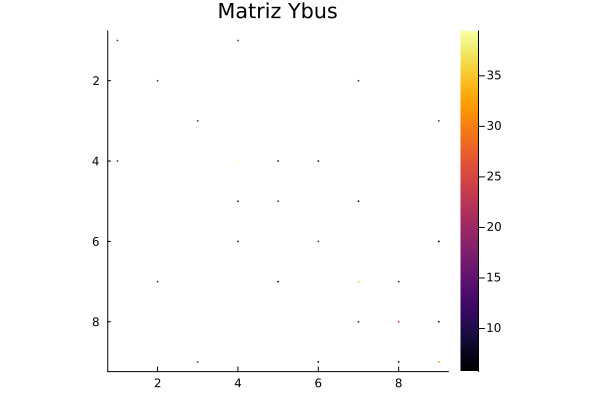

In [3]:
NumN = maximum([maximum([line.n1,line.n2]) for line in Lines])
Ybus = CalcularYbus(Lines)
spy(abs.(Ybus), title="Matriz Ybus")

In [4]:
# Parametros Cargas
NumD = 3
Loads = Array{NamedTuple,1}(undef,NumD);
Loads[1] = (n=5, p=1.25, q=0.50);
Loads[2] = (n=6, p=0.90, q=0.30);
Loads[3] = (n=8, p=1.00, q=0.35);
println("Cargas:",Loads);

Cargas:Vector de Tuplas de tamaño 3
n	p	q	
5	1.25	0.5	
6	0.9	0.3	
8	1.0	0.35	



In [5]:
# Parametros Generadores
NumG = 3;
Generators = Array{NamedTuple,1}(undef,NumG);
Generators[1] = (n=1, x=0.0608, H=23.640);
Generators[2] = (n=2, x=0.1198, H=6.8000);
Generators[3] = (n=3, x=0.1813, H=3.0100);
println("Generadores:",Generators);

Generadores:Vector de Tuplas de tamaño 3
n	x	H	
1	0.0608	23.64	
2	0.1198	6.8	
3	0.1813	3.01	



In [6]:
# Flujo de carga
vn = [1.0400;1.0250;1.0250;1.0258;0.9956;1.0127;1.0258;1.0159;1.0324];
an = [0;9.2800;4.6648;-2.2168;-3.9888;-3.6874;3.7197;0.7275;1.9667];                  
Vnodal = vn.*exp.(an*pi/180*1im);

In [7]:
# Modificar la Ybus con las cargas
Inodal = Ybus*Vnodal
Snodal = Vnodal.*conj.(Inodal)
printstyled("Modelo de las cargas\n",color=:green);
for load in Loads
    z_load = Vnodal[load.n]*conj(Vnodal[load.n]/(load.p+load.q*1im));
    Ybus[load.n,load.n] +=  1/z_load;
    println('z',load.n," : ",z_load)
end

Modelo de las cargas
z5 : 0.6835995586206897 + 0.27343982344827594im
z6 : 1.0255612900000002 + 0.34185376333333334im
z8 : 0.9194234387527839 + 0.32179820356347427im


In [8]:
# Ybus aumentada prefalla y voltajes internos de los generadores
Ngrande = NumN+NumG;
Ygrande = complex(zeros(Ngrande,Ngrande));
N = 1:NumN
Ygrande[N,N] = Ybus;
v_gen = zeros(NumG,1);
a_gen = zeros(NumG,1);

printstyled("Voltaje interno de los generadores\n",color=:green)
for k in 1:NumG
    gen = Generators[k]
    vg = Vnodal[gen.n] + Inodal[gen.n]*gen.x*1im;
    v_gen[k] = abs(vg);
    a_gen[k] = angle(vg);
    n1 = gen.n;
    n2 = gen.n + NumN;
    Ygrande[n1,n1] = Ygrande[n1,n1] + 1/(gen.x*1im);
    Ygrande[n1,n2] = Ygrande[n1,n2] - 1/(gen.x*1im);
    Ygrande[n2,n1] = Ygrande[n2,n1] - 1/(gen.x*1im);
    Ygrande[n2,n2] = Ygrande[n2,n2] + 1/(gen.x*1im);
    println('v',gen.n," : ", abs(vg)," < " ,angle(vg)*180/pi, "p : ", real(Snodal[gen.n]));
end

Voltaje interno de los generadores
v1 : 1.0566296466486635 < 2.2717102959515247p : 0.716422262005308
v2 : 1.0501445445050868 < 19.73245601866423p : 1.6300474043275959
v3 : 1.0168243158602375 < 13.168252359661016p : 0.8500591222115167


In [9]:
# reduccion de nodos de Kron
printstyled("Matriz de prefalla\n",color=:green)
Ypre = KronReduction(Ygrande,NumG);

Matriz de prefalla
ComplexF64[0.8454798908057436 - 2.988281351659996im 0.2871098874472249 + 1.5129404073463204im 0.20958881475256974 + 1.2256197912488034im; 0.2871098874472248 + 1.51294040734632im 0.41998505686296683 - 2.7238651354714634im 0.21326705813033342 + 1.0879325163966211im; 0.2095888147525698 + 1.225619791248803im 0.2132670581303335 + 1.0879325163966211im 0.2769937580789419 - 2.36812818137671im]


In [10]:
# Matriz Falla (falla trifasica en el nodo 7)
printstyled("Matriz en falla\n",color=:green)
n_t = setdiff(1:Ngrande,7); # nodos que no estan en falla
YA = Ygrande[n_t,n_t];
Yfalla = KronReduction(YA,NumG)

Matriz en falla
ComplexF64[0.6567727885586515 - 3.815994303407301im 0.0 + 0.0im 0.07014026136882275 + 0.6305614003173562im; 0.0 + 0.0im 0.0 - 5.4854635216675804im 0.0 + 0.0im; 0.07014026136882277 + 0.6305614003173563im 0.0 + 0.0im 0.17401781585790166 - 2.795910398010307im]


3×3 Matrix{ComplexF64}:
  0.656773-3.81599im   0.0+0.0im      0.0701403+0.630561im
       0.0+0.0im       0.0-5.48546im        0.0+0.0im
 0.0701403+0.630561im  0.0+0.0im       0.174018-2.79591im

In [11]:
# Matriz de postfalla
printstyled("Matriz en post-falla\n",color=:green)
YB = Ygrande;
line = Lines[6]
y_line = 1/(line.r + line.x*1im);
b_cap  = line.b*1im; 
YB[line.n1,line.n1] = YB[line.n1,line.n1] - y_line - b_cap;
YB[line.n1,line.n2] = YB[line.n1,line.n2] + y_line;
YB[line.n2,line.n1] = YB[line.n2,line.n1] + y_line;
YB[line.n2,line.n2] = YB[line.n2,line.n2] - y_line - b_cap;
Ypos = KronReduction(YB,NumG)

Matriz en post-falla
ComplexF64[1.1386163349787186 - 2.2965975359523085im 0.12899726606688844 + 0.706333893060545im 0.18238589453412632 + 1.0637079316915634im; 0.12899726606688836 + 0.7063338930605448im 0.3744387895603565 - 2.015070785158386im 0.19211957196813662 + 1.2066899661570083im; 0.1823858945341262 + 1.0637079316915636im 0.19211957196813667 + 1.2066899661570087im 0.26911487380449317 - 2.351641084011657im]


3×3 Matrix{ComplexF64}:
  1.13862-2.2966im    0.128997+0.706334im  0.182386+1.06371im
 0.128997+0.706334im  0.374439-2.01507im    0.19212+1.20669im
 0.182386+1.06371im    0.19212+1.20669im   0.269115-2.35164im

In [12]:
# Solucion de la ecuacion diferencial
w_base= 2*pi*60
M = [2*gen.H for gen in Generators]
p_mec = [real(Snodal[gen.n]) for gen in Generators]
# solucion de la ecuacion diferencial
t_falla = 0.1;
t_apertura = 0.183;
t_fin = 2.0;
num_steps = 60;
dt = t_fin/num_steps;
gr_delta = zeros(num_steps,NumG);
gr_omega = zeros(num_steps,NumG);
gr_time = (1:num_steps) * dt;

w  = ones(NumG);
for k = 1:num_steps
    if gr_time[k] < t_falla
        Ybus = Ypre;
    elseif gr_time[k] < t_apertura
        Ybus = Yfalla;
    else
        Ybus = Ypos;
    end
    vg = v_gen.*exp.(a_gen*1im);
    ig = Ybus*vg;
    sg = vg.*conj(ig);
    pg = real(sg);
    for i = 1:NumG
        w[i] = w[i] + dt/M[i]*(p_mec[i]-pg[i]);
        a_gen[i] = a_gen[i] + dt*(w[i]-1)*w_base;
        gr_delta[k,i] = a_gen[i]*180/pi;
        gr_omega[k,i] = w[i];
    end
end

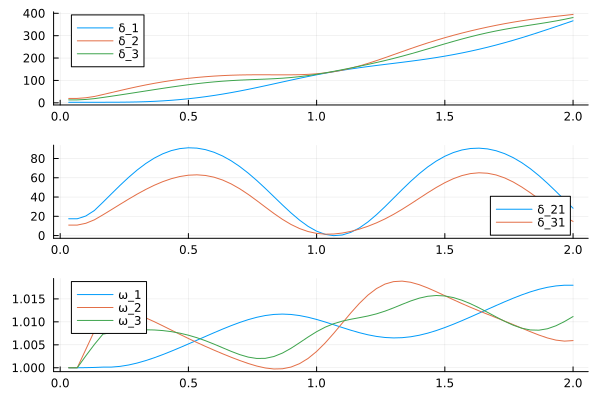

In [22]:
p1 = plot(gr_time,gr_delta,label=["δ_1" "δ_2" "δ_3"])
gr_diff = [gr_delta[:,2]-gr_delta[:,1]  gr_delta[:,3]-gr_delta[:,1]]
p2 = plot(gr_time,gr_diff,label=["δ_21" "δ_31"])
p3 = plot(gr_time,gr_omega,label=["ω_1" "ω_2" "ω_3"])
plt = plot(p1,p2,p3,layout=(3,1))
display(plt)

Comparar con las figuras 2.21 y 2.22 del libro de Anderson.  Las gráficas son exactamente iguales.